In [18]:
import numpy as np
import pandas as pd
import yfinance as yf

from scipy.optimize import minimize

import plotly.express as px
import plotly.graph_objects as go


In [31]:
tickers = ["PCHEM.KL", "CDB.KL", "PETGAS.KL", "IOICORP.KL", "TM.KL", "KLK.KL"]
start = "2021-01-01"
end = "2026-04-30"

prices = yf.download(tickers, start=start, end=end)["Close"].dropna()
returns = prices.pct_change().dropna()

mu = returns.mean() * 252
S = returns.cov() * 252
rf = 0.0331 #risk free rate of Malaysia 5 year GII-Islamic  yield as of 2026-05-07
n = len(tickers)


/var/folders/_8/1sq_bybx4jl69svxqvsf7j200000gn/T/ipykernel_2455/3074411451.py:5: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  6 of 6 completed

5 Failed downloads:
['PCHEM.KL', 'CDB.KL', 'KLK.KL', 'PETGAS.KL', 'TM.KL']: YFTzMissingError('possibly delisted; no timezone found')
/Users/sajidurrahmanshaik/Library/Python/3.9/lib/python/site-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning:

Mean of empty slice.

/Users/sajidurrahmanshaik/Library/Python/3.9/lib/python/site-packages/numpy/_core/_methods.py:130: RuntimeWarning:

invalid value encountered in divide

/Users/sajidurrahmanshaik/Library/Python/3.9/lib/python/site-packages/pandas/core/frame.py:11238: RuntimeWarning:

Degrees of freedom <= 0 for slice

/Users/sajidurrahmanshaik/Library/Python/3.9/lib/python/site-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning:

divide by zero encountered in divide

/Users/sajidurrahmansh

In [32]:
np.random.seed(42)

n_portfolios = 10000 
records = []

for _ in range(n_portfolios):
    w = np.random.rand(n)
    w /= w.sum()

    ret = w @ mu
    vol = np.sqrt(w.T @ S.values @ w)
    sharpe = (ret - rf) / vol

    records.append(np.concatenate(([ret, vol, sharpe], w)))

cols = ["Return", "Volatility", "Sharpe"] + [f"{t}" for t in tickers]
ef_df = pd.DataFrame(records, columns=cols)


To ensure Shariah Compliancy short selling has been disabled as it is a form of riba and maisir.

In [33]:
def portfolio_vol(w):
    return np.sqrt(w.T @ S.values @ w)

constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}
bounds = [(0, 1) for _ in range(n)]

w0 = np.repeat(1/n, n)

gmv_res = minimize(
    portfolio_vol, w0,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

w_gmv = gmv_res.x
gmv_ret = w_gmv @ mu
gmv_vol = portfolio_vol(w_gmv)
gmv_sharpe = (gmv_ret - rf) / gmv_vol


In [34]:
def neg_sharpe(w):
    ret = w @ mu
    vol = np.sqrt(w.T @ S.values @ w)
    return -(ret - rf) / vol

tan_res = minimize(
    neg_sharpe, w0,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

w_tan = tan_res.x
tan_ret = w_tan @ mu
tan_vol = np.sqrt(w_tan.T @ S.values @ w_tan)
tan_sharpe = (tan_ret - rf) / tan_vol


In [35]:
cml_x = np.linspace(0, tan_vol * 2.0, 200)
cml_y = rf + tan_sharpe * cml_x


In [36]:
hover = {
    "Return": ":.2%",
    "Volatility": ":.2%",
    "Sharpe": ":.2f"
}
for t in tickers:
    hover[f"{t}"] = ":.2%"

fig = px.scatter(
    ef_df,
    x="Volatility",
    y="Return",
    color="Sharpe",
    hover_data=hover,
    color_continuous_scale="RdBu",
    template="plotly_white",
    title="Efficient Frontier"
)

fig.add_scatter(
    x=[tan_vol],
    y=[tan_ret],
    mode="markers",
    marker=dict(size=13, color="red", symbol="star"),
    customdata=[np.concatenate(([tan_sharpe], w_tan))],
    hovertemplate=(
        "<b>Tangency Portfolio</b><br>"
        "Return: %{y:.2%}<br>"
        "Volatility: %{x:.2%}<br>"
        "Sharpe: %{customdata[0]:.2f}<br><br>" +
        "<br>".join(
            [f"{t}: %{{customdata[{i+1}]:.2%}}" for i, t in enumerate(tickers)]
        ) +
        "<extra></extra>"
    )
)

fig.add_scatter(
    x=[gmv_vol],
    y=[gmv_ret],
    mode="markers",
    marker=dict(size=11, color="green", symbol="diamond"),
    customdata=[np.concatenate(([gmv_sharpe], w_gmv))],
    hovertemplate=(
        "<b>GMV Portfolio</b><br>"
        "Return: %{y:.2%}<br>"
        "Volatility: %{x:.2%}<br>"
        "Sharpe: %{customdata[0]:.2f}<br><br>" +
        "<br>".join(
            [f"{t}: %{{customdata[{i+1}]:.2%}}" for i, t in enumerate(tickers)]
        ) +
        "<extra></extra>"
    )
)

fig.add_scatter(
    x=cml_x,
    y=cml_y,
    mode="lines",
    line=dict(color="black", dash="dot", width=2),
    hoverinfo="skip"
)

fig.add_annotation(
    x=tan_vol,
    y=tan_ret,
    text=f"Tangency<br>Sharpe: {tan_sharpe:.2f}",
    showarrow=True,
    arrowhead=2
)
fig.add_annotation(
    x=gmv_vol,
    y=gmv_ret,
    text=f"GMV<br>Sharpe: {gmv_sharpe:.2f}",
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    width=1100,
    height=650,
    template="plotly_white",
    showlegend=False
)

fig.update_layout(
    coloraxis=dict( 
        cmin=ef_df["Sharpe"].min(),
        cmax=ef_df["Sharpe"].max()
    )
)

fig.update_layout(
    showlegend=False,
    coloraxis_colorbar=dict(title="Sharpe"),
    xaxis_title="Volatility",
    yaxis_title="Expected Return"
)

fig.show()


Interpretation of efficient frontier

 1- Tangency Portolio: This portfolio offers a high expected return of 20.19% with a volatility of 15% and a Sharpe ratio of 1.07, indicating strong risk-adjusted performance. The allocation heavily favors high-growth technology stocks like MSFT and NFLX, complemented by gold as a hedge against market volatility and bonds for modest stability. This mirrors real-world investment strategies where investors blend high-risk equities with hedging instruments to optimize returns without exposing themselves to extreme losses.

 2- Global Minimum Variance (GMV) Portfolio: With an expected return of only 5.52% and volatility of 7.7%, this portfolio prioritizes capital preservation over growth, resulting in a low Sharpe ratio of 0.17. Its allocation is dominated by stable, low-volatility stocks like KO and supported by bonds, reflecting a conservative approach typical of risk-averse investors such as retirees or institutions seeking predictable cash flows. In the real world, such a portfolio reduces exposure to market shocks but sacrifices potential upside during bull markets.

 The efficient frontier provides a roadmap for balancing risk and return in practice. While the tangency portfolio represents the optimal strategy for maximizing risk-adjusted returns, the GMV portfolio exemplifies a safety-first approach. Together, they emphasize that real-world portfolio management involves making deliberate trade-offs between potential reward and exposure to market uncertainties.


In [37]:
ret_tan = returns @ w_tan
ret_gmv = returns @ w_gmv
ret_eq  = returns @ np.repeat(1/n, n)

cum_tan = (1 + ret_tan).cumprod()
cum_gmv = (1 + ret_gmv).cumprod()
cum_eq  = (1 + ret_eq).cumprod()


In [38]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=cum_tan.index,
    y=cum_tan,
    line=dict(color="red", width=2),
    name="Tangency"
))

fig.add_trace(go.Scatter(
    x=cum_gmv.index,
    y=cum_gmv,
    line=dict(color="green", width=2),
    name="GMV"
))



fig.add_trace(go.Scatter(
    x=cum_eq.index,
    y=cum_eq,
    line=dict(color="blue", width=2),
    name="Equal-Weighted"
))


fig.update_layout(
    template="plotly_white",  
    showlegend=False,
    title="Backtest Performance (Tangency vs Equal weight vs GMV Portfolio )",
    yaxis_title="Portfolio Value",
    xaxis_title = "Year",
    hovermode="x unified",
    width = 1100,
    height = 650,
)

fig.show()

fig.write_html("backtest_chart3.html", auto_open= False)


In [39]:
def summary_stats(r, rf=0.0419):
    ann_ret = r.mean() * 252
    ann_vol = r.std() * np.sqrt(252)
    sharpe = (ann_ret - rf) / ann_vol
    return ann_ret, ann_vol, sharpe


summary = pd.DataFrame(
    {
        "Tangency": summary_stats(ret_tan),
        "GMV": summary_stats(ret_gmv),
        "Equal-Weighted": summary_stats(ret_eq)
    },
    index=["Annual Return", "Annual Volatility", "Sharpe Ratio"]
)

summary.style.format({
    "Tangency": "{:.3f}",
    "GMV": "{:.3f}",
    "Equal-Weighted": "{:.3f}"
})

,Tangency,GMV,Equal-Weighted
Annual Return,nan,nan,nan
Annual Volatility,nan,nan,nan
Sharpe Ratio,nan,nan,nan


The optimized tangency portfolio delivered the strongest results, with a return of 20.2% and a Sharpe ratio of 1.07, thanks to its heavy allocation to Microsoft, Netflix, and gold. This mix captured the surge in technology and streaming demand during lockdowns while gold provided a hedge against uncertainty and inflation, making it well-suited for the pandemic environment. The equal weight portfolio, with a return of 16.4% and a Sharpe ratio of 0.91, offered a balanced approach by diversifying across all assets. While it did not outperform the optimized portfolio, its diversification cushioned losses during market shocks (COVID-19 period) and still benefited from exposure to tech and gold. In contrast, the GMV portfolio prioritized stability, allocating 70.32% to Coca-Cola and significant weight to LQD at 11.97%, resulting in the lowest return of 5.5% and a Sharpe ratio of just 0.17. This conservative stance would have felt safe during the initial COVID crash as it can be seen in the dip during the period as compared to the other portfolios but it missed the explosive recovery driven by growth assets. Taken together, the results show that the tangency portfolio was best positioned to thrive in a crisis-driven market, the equal weight portfolio provided resilience through diversification, and the GMV portfolio offered safety at the cost of opportunity.

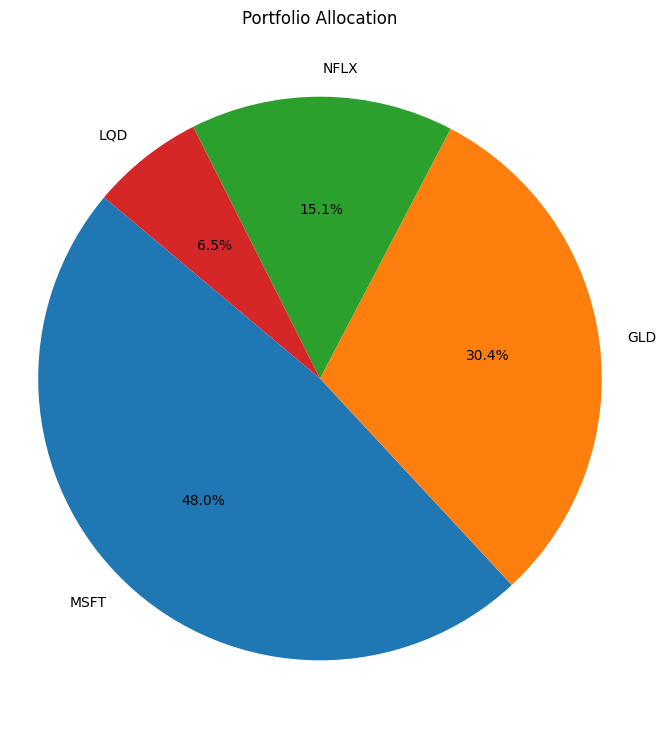

In [40]:
import matplotlib.pyplot as plt

# Portfolio data
labels = ['MSFT', 'GLD', 'NFLX', 'LQD']
sizes = [48.03, 30.42, 15.10, 6.46]  # percentages
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # optional custom colors

# Create pie chart
plt.figure(figsize=(8, 9))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Portfolio Allocation')
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular
plt.show()
